In [2]:
# EDA 

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')
import os

In [4]:
data=pd.read_csv(r"C:\Users\ajayt\OneDrive\Desktop\DataSets\train.csv")

In [5]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
data.isna().sum() # checking for total null values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

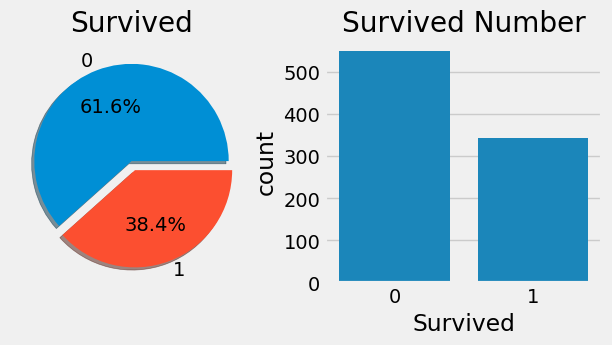

In [10]:
f,ax=plt.subplots(1,2,figsize=(7,3))
data['Survived'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Survived')

sns.countplot(x='Survived',data=data,ax=ax[1])
ax[1].set_title('Survived Number')
plt.show()

In [ ]:
#Analysis the Feature



In [11]:
data.groupby(["Sex","Survived"])["Survived"].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

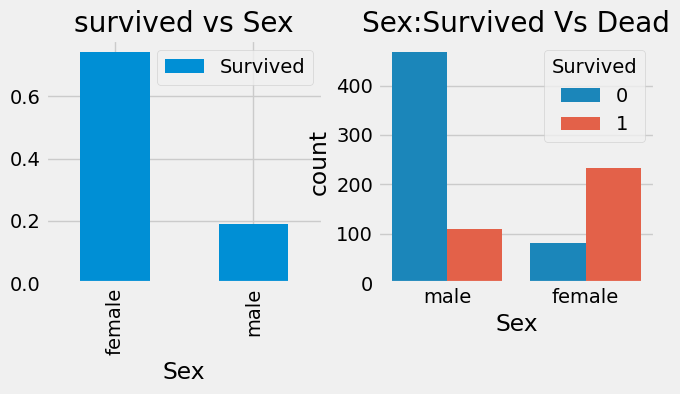

In [13]:
f,ax=plt.subplots(1,2 ,figsize=(7,3))
data[["Sex","Survived"]].groupby(["Sex"]).mean().plot.bar(ax=ax[0])
ax[0].set_title("survived vs Sex")
sns.countplot(x="Sex",hue="Survived",data=data,ax=ax[1])
#Sns.countplot(data,x="Sex",ax=ax[1])
ax[1].set_title("Sex:Survived Vs Dead")
plt.show()

In [ ]:
#Pesenger class +>> Ordinal Feature

In [14]:
pd.crosstab(data.Pclass,data.Survived,margins=True).style.background_gradient(cmap="summer")

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


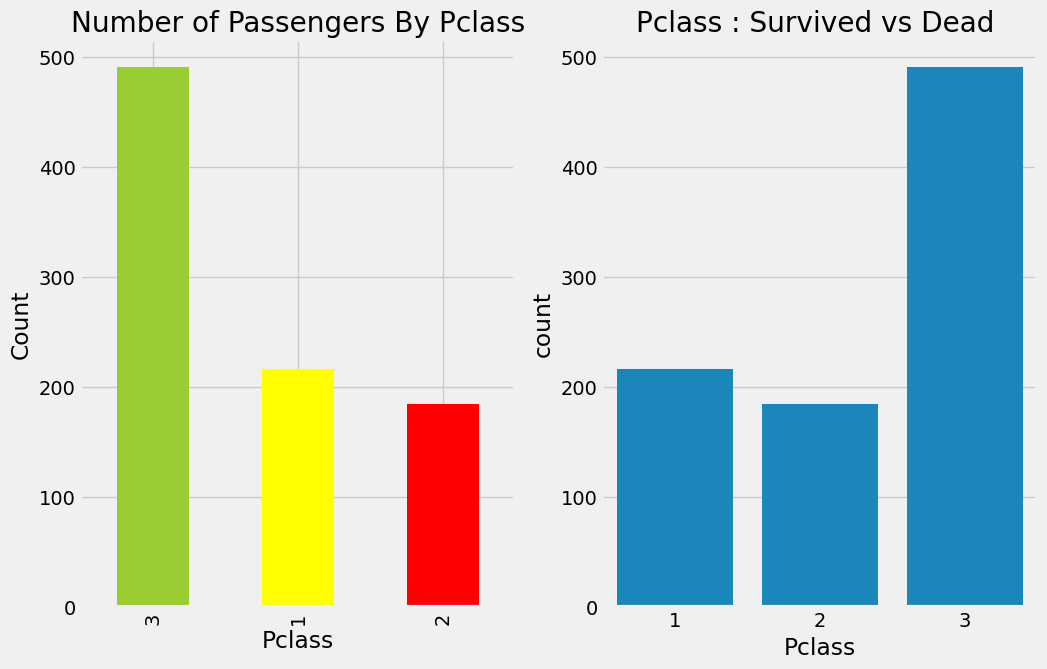

In [16]:
f,ax=plt.subplots(1,2,figsize=(11,7))
data["Pclass"].value_counts().plot.bar(color=['yellowgreen','yellow','red'],ax=ax[0])
ax[0].set_title("Number of Passengers By Pclass")
ax[0].set_ylabel('Count')
sns.countplot(x='Pclass',data=data,ax=ax[1])
ax[1].set_title("Pclass : Survived vs Dead ")
plt.show()
                

In [17]:
pd.crosstab([data.Sex,data.Survived],data.Pclass,margins=True).style.background_gradient(cmap="GnBu")

In [20]:
sns.factorplot('Pclass','Survived',hue='Sex',data=data)   #depricated
plt.show()

TypeError: catplot() got multiple values for argument 'data'

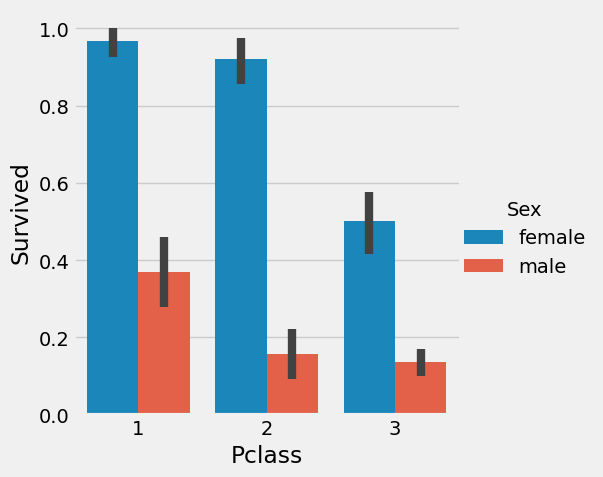

In [21]:
sns.catplot(x='Pclass', y='Survived', hue='Sex', data=data, kind='bar')
plt.show()

In [22]:
# Age == Continous feature
print("Oldest Passengerwas of :",data["Age"].max(),"Years")
print("Yongest Passanger was of :",data["Age"].min(),"Years")
print("Average Age on the ship :",data["Age"].mean(),"Years")

Oldest Passengerwas of : 80.0 Years
Yongest Passanger was of : 0.42 Years
Average Age on the ship : 29.69911764705882 Years


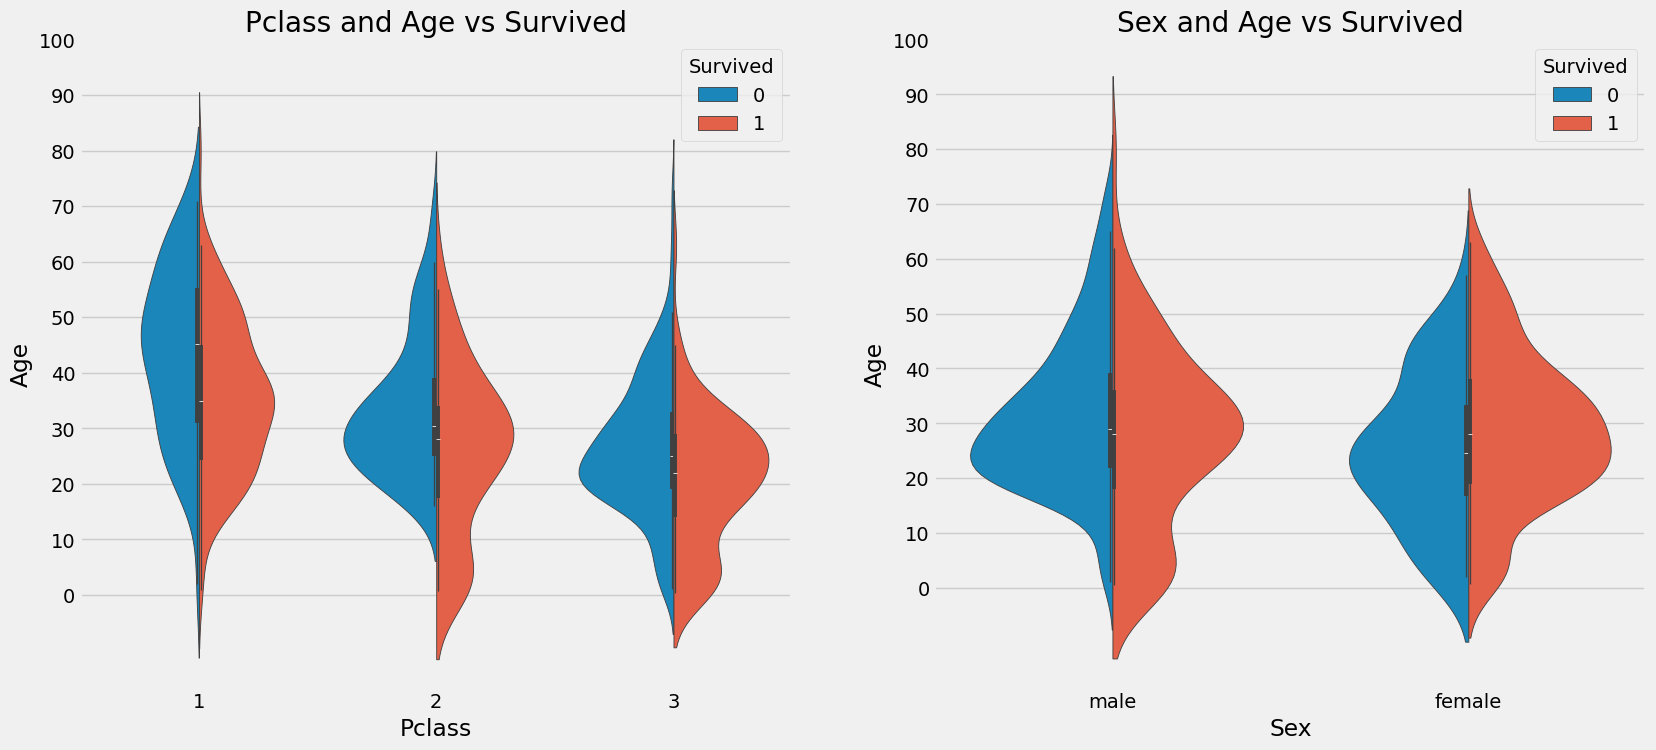

In [24]:
f,ax=plt.subplots(1,2,figsize=(18,8))
sns.violinplot(x="Pclass",y="Age",hue="Survived",data=data,split=True,ax=ax[0])
ax[0].set_title("Pclass and Age vs Survived")
ax[0].set_yticks(range(0,110,10))
sns.violinplot(x="Sex",y="Age",hue="Survived",data=data,split=True,ax=ax[1])
ax[1].set_title("Sex and Age vs Survived")
ax[1].set_yticks(range(0,110,10))
plt.show()

In [ ]:
#Observations
#1)The number of Children Increases with Pclass 

In [25]:
data["Initial"]=0
for i in data:
    data["Initial"]=data.Name.str.extract("([A-Za-z]+)\.") #Lets extract the solutions
data["Initial"].head(15)

0         Mr
1        Mrs
2       Miss
3        Mrs
4         Mr
5         Mr
6         Mr
7     Master
8        Mrs
9        Mrs
10      Miss
11      Miss
12        Mr
13        Mr
14      Miss
Name: Initial, dtype: str

In [ ]:
# SibSP Sibling //

sns.barplot(x="SibSp")

In [7]:
#Correlation Between The Features
sns.heatmap(data.corr(),annot=True,cmap="RdYlGn",linewidths=0.2)
fig-plt.gcf()
fig.set_size_inches(10,8)
plt.show()


ValueError: could not convert string to float: 'Braund, Mr. Owen Harris'

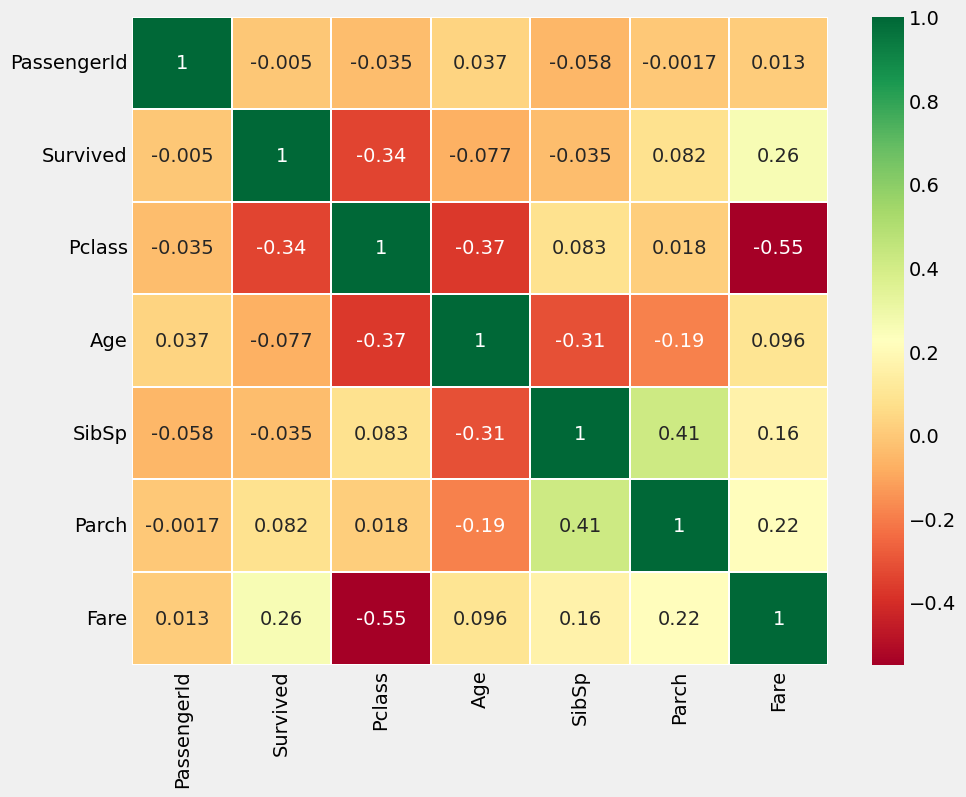

In [12]:
# numeric_data = data.select_dtypes(include=['int64','float64'])

# Correlation heatmap
sns.heatmap(numeric_data.corr(), annot=True, cmap="RdYlGn", linewidths=0.2)

fig = plt.gcf()
fig.set_size_inches(10, 8)

plt.show()

In [ ]:
data["Age_band"]=0
data.loc[data["Age"]<=16,"Age"]

In [ ]:
data["Age_band"].value

In [ ]:
Family_Size and Alone
Data["Family_size"]=0
data["Family_size"]=data["Parch"]+data

In [13]:
#Fare_Range   qcut ( convert in bins or in range)

data["Fare_cat"]= pd.qcut(data["Fare"],4)
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Fare_cat
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,"(-0.001, 7.91]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,"(31.0, 512.329]"
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,"(7.91, 14.454]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,"(31.0, 512.329]"
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,"(7.91, 14.454]"


In [18]:
data.groupby(["Fare_Range"])["Survived"].mean().to_frame().style.background_gredinent(cmap="summer_r")


KeyError: 'Fare_Range'

In [22]:
data.drop(["Name","Age","Ticket","Fare","Cabin","Fare_Range","PassengerId"],axis=1,inplace=True)
sns.heat

KeyError: "['Fare_Range'] not found in axis"

In [ ]:
#Leniar Regression